In [88]:
!pip install ipykernel pandas kagglehub openpyxl seaborn scipy


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Dataset Download

In [75]:
import kagglehub
import os
import shutil

# Download latest version

# Download dataset and get the cache path
cache_path =  kagglehub.dataset_download("nayakganesh007/nike-sales-uncleaned-dataset")

# Get current working directory 
notebook_dir = os.getcwd()

# Define destination folder
dest_path = os.path.join(notebook_dir, "NikeDataset")

# Copy dataset into your notebook folder

shutil.copytree(cache_path, dest_path)

print("Success. Dataset downloaded to:", dest_path)

Success. Dataset downloaded to: f:\GitHub\CSC0413_CS-Elective-II_Activity-1\NikeDataset


# Dataset Cleaning

In [76]:
import pandas as pd
df = pd.read_csv(os.path.join(dest_path, "Nike_Sales_Uncleaned.csv"))

### Check for missing values

In [77]:
df.isnull().sum()

Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name           0
Size                 510
Units_Sold          1235
MRP                 1254
Discount_Applied    1668
Revenue                0
Order_Date           616
Sales_Channel          0
Region                 0
Profit                 0
dtype: int64

### Since there is null values on certain cells we need to remove or edit that row

In [78]:
# Fill Size nulls with "Unknown"
df['Size'] = df['Size'].fillna("Unknown")

# Fill Units_Sold, MRP, Discount_Applied with 0
df['Units_Sold'] = df['Units_Sold'].fillna(0)
df['MRP'] = df['MRP'].fillna(0)
df['Discount_Applied'] = df['Discount_Applied'].fillna(0)

# Drop rows where Order_Date is null
df = df.dropna(subset=['Order_Date'])
df.isnull().sum()

Order_ID            0
Gender_Category     0
Product_Line        0
Product_Name        0
Size                0
Units_Sold          0
MRP                 0
Discount_Applied    0
Revenue             0
Order_Date          0
Sales_Channel       0
Region              0
Profit              0
dtype: int64

### Check for Datatype

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1884 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1884 non-null   int64  
 1   Gender_Category   1884 non-null   object 
 2   Product_Line      1884 non-null   object 
 3   Product_Name      1884 non-null   object 
 4   Size              1884 non-null   object 
 5   Units_Sold        1884 non-null   float64
 6   MRP               1884 non-null   float64
 7   Discount_Applied  1884 non-null   float64
 8   Revenue           1884 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     1884 non-null   object 
 11  Region            1884 non-null   object 
 12  Profit            1884 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 206.1+ KB


### Fix the Date of Order Date

In [80]:
from dateutil import parser

# Load dataset
def fix_date(x):
    if pd.isna(x) or str(x).strip() == "":
        return ""  # keep missing blank
    try:
        return parser.parse(str(x), dayfirst=True).strftime("%Y-%m-%d")
    except Exception:
        return ""  # if totally invalid

# Apply to Order_Date column
df["Order_Date"] = df["Order_Date"].apply(fix_date)

print(df[["Order_ID","Order_Date"]].head(15))


    Order_ID  Order_Date
0       2000  2024-09-03
1       2001  2024-09-07
3       2003  2024-10-04
4       2004  2024-12-09
6       2006  2025-06-04
8       2008  2024-10-11
10      2010  2025-01-16
12      2018  2024-11-13
13      2013  2024-09-19
14      2014  2025-12-04
15      2015  2025-05-31
17      2017  2025-03-17
19      2019  2025-01-17
20      2020  2025-03-28
21      2021  2024-11-19


### Check for duplicate

In [81]:
df.duplicated().sum()

np.int64(0)

### Check for Spelling and Typographical Errors

In [82]:
# Check for duplicate rows (all columns)
duplicates = df[df.duplicated()]

# Count duplicates
num_duplicates = df.duplicated().sum()

print(f"Total duplicate rows: {num_duplicates}")

Total duplicate rows: 0


### Checking Typos

In [83]:
print(df['Product_Line'].unique())
print(df['Region'].unique())
df['Region'] = df['Region'].str.strip().str.title()
region_map = {
    "Bengaluru": "Bangalore",
    "Hyd": "Hyderabad",
    "Hyderbad": "Hyderabad"
}

df['Region'] = df['Region'].replace(region_map)
print(df['Product_Line'].unique())
print(df['Region'].unique())

# Columns that should never be negative
non_negative_cols = ["Order_ID", "Units_Sold", "MRP", "Discount_Applied"]

# Check for negatives in those columns
for col in non_negative_cols:
    negatives = df[df[col] < 0]
    print(f"{col}: {len(negatives)} rows with negative values")
    if not negatives.empty:
        display(negatives.head()) 

# Revenue and Profit special check
print("\nRevenue min:", df['Revenue'].min())
print("Profit min:", df['Profit'].min())



['Training' 'Soccer' 'Lifestyle' 'Running' 'Basketball']
['bengaluru' 'Hyd' 'Pune' 'Delhi' 'Bangalore' 'Hyderabad' 'hyderbad'
 'Kolkata' 'Mumbai']
['Training' 'Soccer' 'Lifestyle' 'Running' 'Basketball']
['Bangalore' 'Hyderabad' 'Pune' 'Delhi' 'Kolkata' 'Mumbai']
Order_ID: 0 rows with negative values
Units_Sold: 158 rows with negative values


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
8,2008,Women,Soccer,Premier III,11,-1.0,0.0,0.00,0.00,2024-10-11,Online,Hyderabad,-731.18
12,2018,Kids,Lifestyle,Blazer Mid,Unknown,-1.0,0.0,0.86,0.00,2024-11-13,Online,Delhi,2109.48
20,2020,Kids,Soccer,Tiempo Legend,L,-1.0,0.0,0.67,0.00,2025-03-28,Retail,Mumbai,439.96
21,2021,Men,Running,Free RN,L,-1.0,7086.7,0.66,-2409.48,2024-11-19,Retail,Hyderabad,-1120.49
54,2054,Women,Training,Flex Trainer,11,-1.0,0.0,0.00,0.00,2025-06-23,Online,Mumbai,-549.76


MRP: 0 rows with negative values
Discount_Applied: 0 rows with negative values

Revenue min: -7561.59
Profit min: -1199.45


### Detecting outlier

In [84]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Profit']

z_outliers = {}
for col in numeric_cols:
    mean = df[col].mean()
    std = df[col].std()
    z_scores = (df[col] - mean) / std
    z_outliers[col] = df[np.abs(z_scores) > 3]
    
    print(f"{col}: {len(z_outliers[col])} outliers")


Units_Sold: 0 outliers
MRP: 0 outliers
Discount_Applied: 0 outliers
Revenue: 42 outliers
Profit: 0 outliers


In [ ]:
os.makedirs("dataset", exist_ok=True)

# Save to CSV
df.to_csv("NikeDataset/cleaned_dataset.csv", index=False)

### Descriptive

In [ ]:
asdsa

### Diagnostic

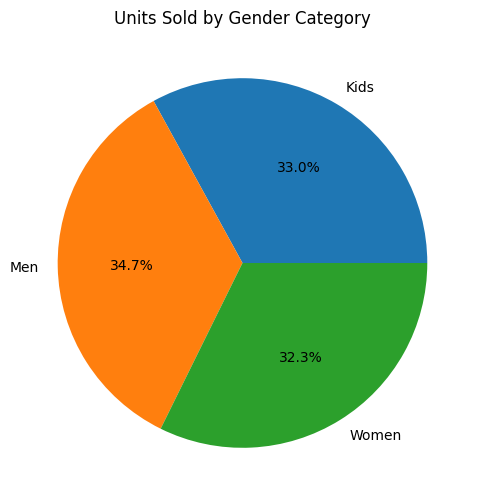

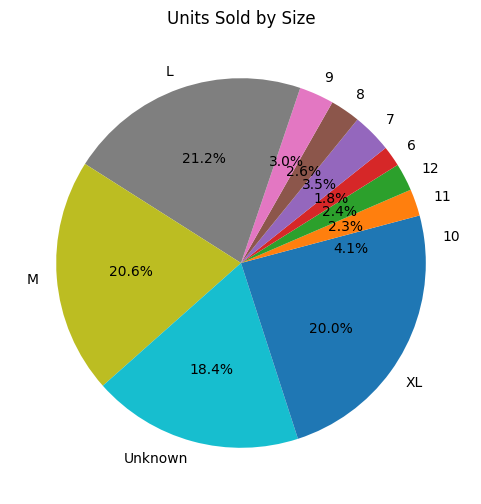

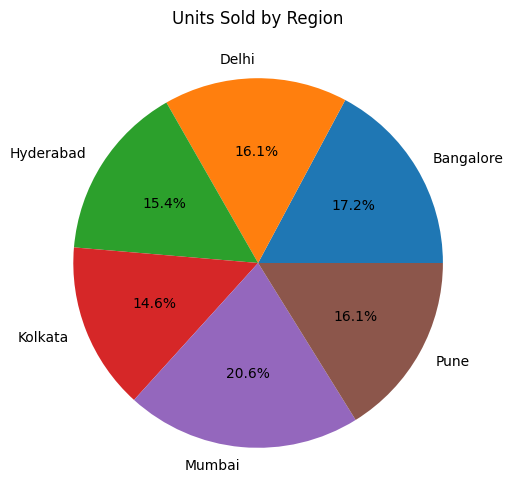

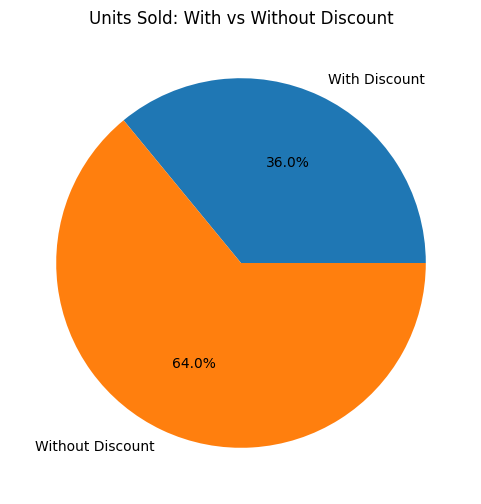

In [86]:
colors = plt.get_cmap('Blues')(np.linspace(0.2, 0.7, len(df)))

gender_units = df.groupby("Gender_Category")["Units_Sold"].sum()
gender_units = gender_units[gender_units > 0]  # remove 0 values

if not gender_units.empty:
    plt.figure(figsize=(6,6))
    plt.pie(gender_units, labels=gender_units.index, autopct='%1.1f%%')
    plt.title("Units Sold by Gender Category")
    plt.show()

# Pie chart: Units Sold by Size
size_units = df.groupby("Size")["Units_Sold"].sum()
size_units = size_units[size_units > 0]

if not size_units.empty:
    plt.figure(figsize=(6,6))
    plt.pie(size_units, labels=size_units.index, autopct='%1.1f%%')
    plt.title("Units Sold by Size")
    plt.show()

# Pie chart: Units Sold by Region
region_units = df.groupby("Region")["Units_Sold"].sum()
region_units = region_units[region_units > 0]

if not region_units.empty:
    plt.figure(figsize=(6,6))
    plt.pie(region_units, labels=region_units.index, autopct='%1.1f%%')
    plt.title("Units Sold by Region")
    plt.show()

# Group into "With Discount" and "Without Discount"
df['Discount_Status'] = df['Discount_Applied'].apply(lambda x: "With Discount" if x > 0 else "Without Discount")

discount_units = df.groupby("Discount_Status")["Units_Sold"].sum()

# Remove categories with 0 total units
discount_units = discount_units[discount_units > 0]

# Plot pie chart
if not discount_units.empty:
    plt.figure(figsize=(6,6))
    plt.pie(discount_units, labels=discount_units.index, autopct='%1.1f%%')
    plt.title("Units Sold: With vs Without Discount")
    plt.show()
else:
    print("No non-zero Units_Sold data available for plotting.")

### Presriptive

### Predictive